In [2]:
import numpy as np

A = np.arange(1, 26).reshape(5, 5)
A

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

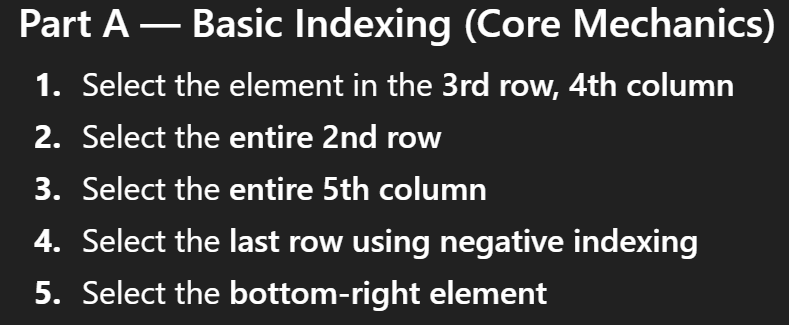

In [8]:
# 1. Select the element in the 3rd row, 4th column.
print(A[2, 3], "\n")

# 2. Select the entire 2nd row.
print(A[1], "\n")

# 3. Select the entire 5th row.
print(A[:, 4], "\n")

# 4. Select the last row using negative indexing
print(A[-1], "\n")

# 5. Select the bottom-right element
print(A[-1, -1], "\n")

14 

[ 6  7  8  9 10] 

[ 5 10 15 20 25] 

[21 22 23 24 25] 

25 



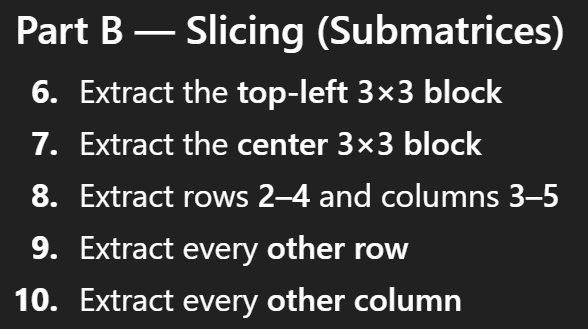

In [33]:
# 6. Extract the top-left 3×3 block
print(A[:3, :3], "\n")

# 7. Extract the center 3×3 block
print(A[1:4, 1:4], "\n")

# 8. Extract rows 2–4 and columns 3–5
print(A[1:4, 2:5], "\n")

# 9. Extract every other row
print(A[::2, :], "\n")

# 10. Extract every other column
print(A[:, ::-1], "\n")

[[ 1  2  3]
 [ 6  7  8]
 [11 12 13]] 

[[ 7  8  9]
 [12 13 14]
 [17 18 19]] 

[[ 8  9 10]
 [13 14 15]
 [18 19 20]] 

[[ 1  2  3  4  5]
 [11 12 13 14 15]
 [21 22 23 24 25]] 

[[ 5  4  3  2  1]
 [10  9  8  7  6]
 [15 14 13 12 11]
 [20 19 18 17 16]
 [25 24 23 22 21]] 



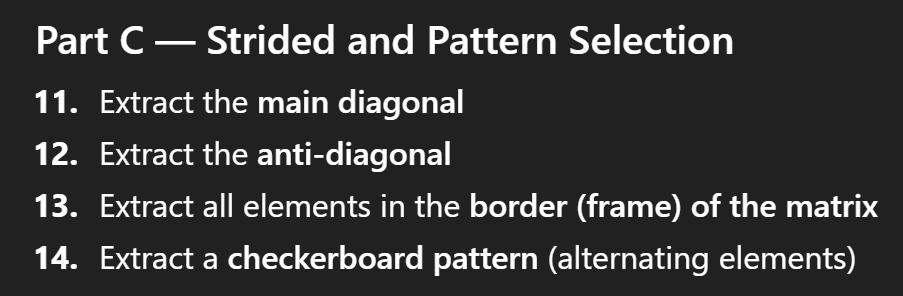

In [32]:
# 11. Extract the main diagonal
print(np.diag(A), "\n")

# 12. Extract the anti-diagonal
print(np.diag(np.fliplr(A)), "\n")

# 13. Extract all elements in the border (frame) of the matrix
top = A[0, :]
left = A[:, 0]
bottom = A[-1, :]
right = A[:, -1]

print(np.concatenate((top, left, bottom, right)), "\n")

# 14.

[ 1  7 13 19 25] 

[ 5  9 13 17 21] 

[ 1  2  3  4  5  1  6 11 16 21 21 22 23 24 25  5 10 15 20 25] 

[[ 5  4  3  2  1]
 [10  9  8  7  6]
 [15 14 13 12 11]
 [20 19 18 17 16]
 [25 24 23 22 21]] 



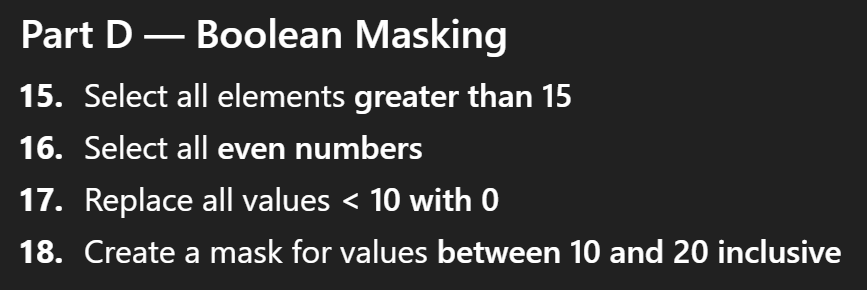

In [40]:
# 15. Select all elements greater than 15
mask = A > 15
print(A[mask], "\n")

# 16. Select all even numbers
mask = (A % 2 == 0)
print(A[mask], "\n")

# 17. Replace all values < 10 with 0
print(np.where(A < 10, 0, A), "\n")

# 18. Create a mask for values between 10 and 20 inclusive
mask = (A >= 10) & (A <= 20)
print(A[mask], "\n")

[16 17 18 19 20 21 22 23 24 25] 

[ 2  4  6  8 10 12 14 16 18 20 22 24] 

[[ 0  0  0  0  0]
 [ 0  0  0  0 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]] 

[10 11 12 13 14 15 16 17 18 19 20] 



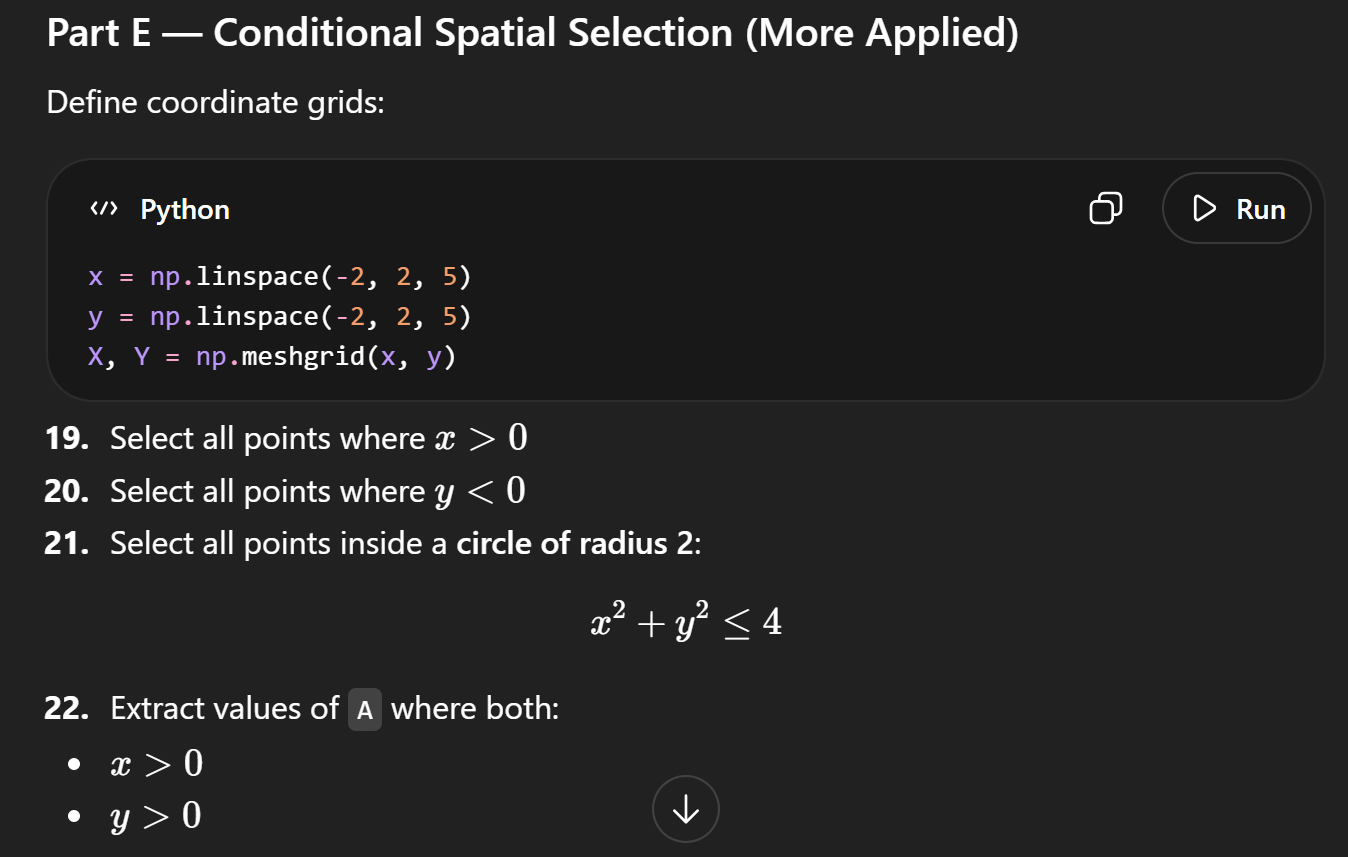

In [45]:
x = np.linspace(-2, 2, 5)
y = np.linspace(-2, 2, 5)
X, Y = np.meshgrid(x, y)

# 19. Select all points where x>0
print(A[X > 0], "\n")

# 20. Select all points where y<0
print(A[Y < 0], "\n")

# 21. inside circle: x^2 + y^2 ≤ 4
mask_circle = X**2 + Y**2 <= 4
A[mask_circle]

[ 4  5  9 10 14 15 19 20 24 25] 

[ 1  2  3  4  5  6  7  8  9 10] 



array([ 3,  7,  8,  9, 11, 12, 13, 14, 15, 17, 18, 19, 23])

In [43]:
X

array([[-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.],
       [-2., -1.,  0.,  1.,  2.]])

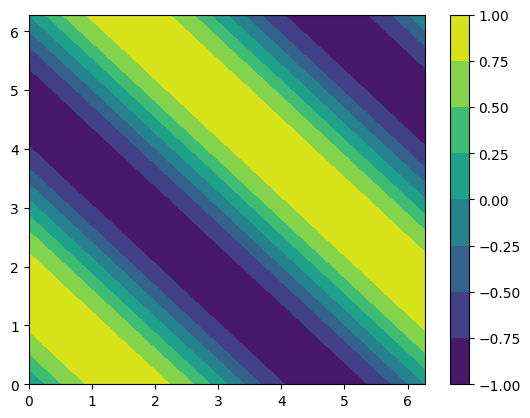

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from src import total_derivatives

x = np.linspace(0, 2*np.pi, 11)
y = np.linspace(0, 2*np.pi, 11)
X, Y = np.meshgrid(x, y)

f = np.sin(X + Y)

fig, ax = plt.subplots()
c = ax.contourf(X, Y, f)
fig.colorbar(c)
plt.show()

In [60]:
j = np.argmin(np.abs(y - 3))
row = f[j, :]

row

array([ 1.22464680e-16, -5.87785252e-01, -9.51056516e-01, -9.51056516e-01,
       -5.87785252e-01, -2.44929360e-16,  5.87785252e-01,  9.51056516e-01,
        9.51056516e-01,  5.87785252e-01,  3.67394040e-16])

In [64]:
total_derivatives.biased_central_difference_approximation(f[j, :], x)

array([-0.93548928, -0.75682673, -0.28908209,  0.28908209,  0.75682673,
        0.93548928,  0.75682673,  0.28908209, -0.28908209, -0.75682673,
       -0.93548928])

In [69]:
dfdx = np.zeros_like(f)

for i in range(f.shape[0]):   # loop over rows (y-direction)
    dfdx[i, :] = total_derivatives.biased_central_difference_approximation(
        f[i, :], x
    )

In [70]:
dfdx

array([[ 9.35489284e-01,  7.56826729e-01,  2.89082087e-01,
        -2.89082087e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01],
       [ 5.78164173e-01,  2.89082087e-01, -2.89082087e-01,
        -7.56826729e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
         9.35489284e-01,  9.35489284e-01],
       [ 1.76697482e-16, -2.89082087e-01, -7.56826729e-01,
        -9.35489284e-01, -7.56826729e-01, -2.89082087e-01,
         2.89082087e-01,  7.56826729e-01,  9.35489284e-01,
         7.56826729e-01,  5.78164173e-01],
       [-5.78164173e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01,  7.56826729e-01,
         2.89082087e-01,  1.76697482e-16],
       [-9.35489284e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
  

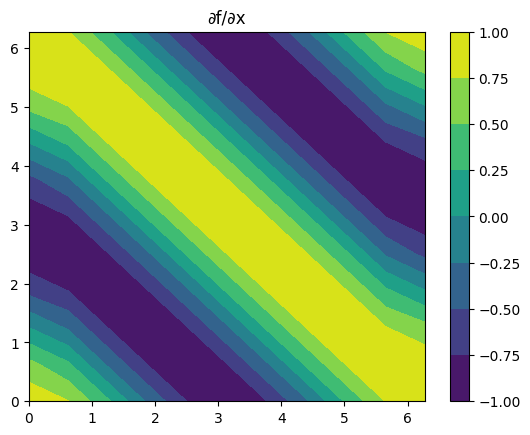

In [71]:
fig, ax = plt.subplots()
c = ax.contourf(X, Y, dfdx)
fig.colorbar(c)
ax.set_title("∂f/∂x")
plt.show()

In [72]:
dfdx = np.apply_along_axis(
    total_derivatives.biased_central_difference_approximation,
    axis=1,
    arr=f,
    domain=x
)

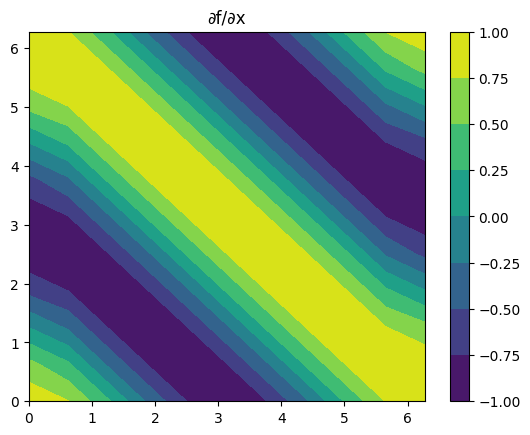

In [73]:
fig, ax = plt.subplots()
c = ax.contourf(X, Y, dfdx)
fig.colorbar(c)
ax.set_title("∂f/∂x")
plt.show()

In [74]:
dfdx

array([[ 9.35489284e-01,  7.56826729e-01,  2.89082087e-01,
        -2.89082087e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01],
       [ 5.78164173e-01,  2.89082087e-01, -2.89082087e-01,
        -7.56826729e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
         9.35489284e-01,  9.35489284e-01],
       [ 1.76697482e-16, -2.89082087e-01, -7.56826729e-01,
        -9.35489284e-01, -7.56826729e-01, -2.89082087e-01,
         2.89082087e-01,  7.56826729e-01,  9.35489284e-01,
         7.56826729e-01,  5.78164173e-01],
       [-5.78164173e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01,  7.56826729e-01,
         2.89082087e-01,  1.76697482e-16],
       [-9.35489284e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
  

In [75]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])

    def biased_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def biased_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

In [79]:
Partial(f, x, y).dx()

array([[ 9.35489284e-01,  7.56826729e-01,  2.89082087e-01,
        -2.89082087e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01],
       [ 5.78164173e-01,  2.89082087e-01, -2.89082087e-01,
        -7.56826729e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
         9.35489284e-01,  9.35489284e-01],
       [ 1.76697482e-16, -2.89082087e-01, -7.56826729e-01,
        -9.35489284e-01, -7.56826729e-01, -2.89082087e-01,
         2.89082087e-01,  7.56826729e-01,  9.35489284e-01,
         7.56826729e-01,  5.78164173e-01],
       [-5.78164173e-01, -7.56826729e-01, -9.35489284e-01,
        -7.56826729e-01, -2.89082087e-01,  2.89082087e-01,
         7.56826729e-01,  9.35489284e-01,  7.56826729e-01,
         2.89082087e-01,  1.76697482e-16],
       [-9.35489284e-01, -9.35489284e-01, -7.56826729e-01,
        -2.89082087e-01,  2.89082087e-01,  7.56826729e-01,
  

In [80]:
f.shape[0]

11

In [81]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])

    def biased_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def biased_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)
X, Y = np.meshgrid(x, y)

psi = X * (1 - X) * Y * (1 - Y)

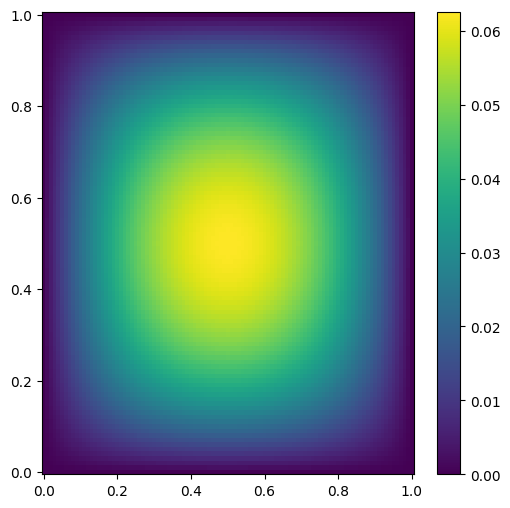

In [82]:
fig, ax = plt.subplots(figsize=(6, 6))
c = ax.pcolormesh(X, Y, psi)
fig.colorbar(c)
plt.show()

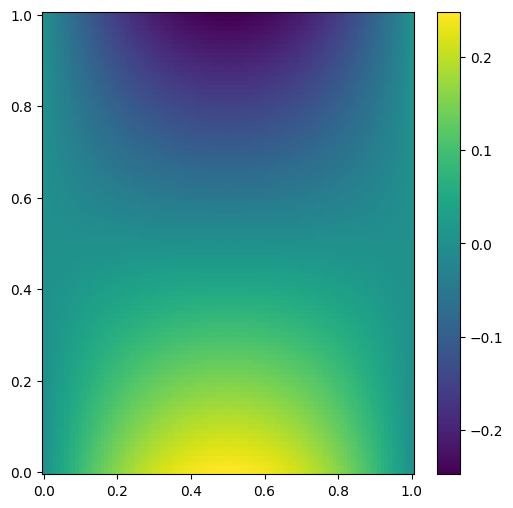

In [83]:
u = Partial(psi, x, y).biased_dy()

fig, ax = plt.subplots(figsize=(6, 6))
c = ax.pcolormesh(X, Y, u)
fig.colorbar(c)
plt.show()



In [93]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> \
            None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])


    def x_is_periodic(self) -> bool:
        """
        Check if function is periodic in x-direction.
        Compares first and last columns.
        """
        return np.allclose(self.function[:, 0], self.function[:, -1])


    def y_is_periodic(self) -> bool:
        """
        Check if function is periodic in y-direction.
        Compares first and last rows.
        """
        return np.allclose(self.function[0, :], self.function[-1, :])


    def biased_dx(self) -> np.ndarray:
        """
        Uses central difference approximation for interior points, forward difference approximation
         at the first point, and backwards difference approximation at the last point to compute the
         partial derivative with respect to x-direction.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def periodic_dx(self) -> np.ndarray:
        """Uses periodic wrapping at boundaries along with central difference approximation
         to compute the partial derivative with respect to x-direction."""
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def biased_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def periodic_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def dx(self):
        if self.x_is_periodic():
            return self.periodic_dx()
        else:
            return self.biased_dx()


    def dy(self):
        if self.y_is_periodic():
            return self.periodic_dy()
        else:
            return self.biased_dy()


    def biased_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def periodic_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def biased_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def periodic_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def dxx(self):
        """Compute the second order partial derivative with respect to x-direction
        with the most appropriate scheme."""
        if self.x_is_periodic():
            return self.periodic_dxx()
        else:
            return self.biased_dxx()


    def dyy(self):
        """Compute the second order partial derivative with respect to y-direction
        with the most appropriate scheme."""
        if self.y_is_periodic():
            return self.periodic_dyy()
        else:
            return self.biased_dyy()


    def at_x0(self, x0: float) -> np.ndarray:
        x0 = np.argmin(self.x - x0)
        return None


    def __str__(self) -> str:
        return (
            f"Partial(field shape = {self.function.shape},"
            f"x = {self.x},"
            f"y = {self.y}),"
            f"x_periodic={self.x_is_periodic()}, "
            f"y_periodic={self.y_is_periodic()})"
        )


    def __repr__(self) -> str:
        return (
            f"Partial(function=np.array(shape={self.function.shape}), "
            f"x=np.array(len={len(self.x)}), "
            f"y=np.array(len={len(self.y)}))"
        )


    def __add__(self, other):
        if not isinstance(other, Partial):
            return NotImplemented

        if self.function.shape != other.function.shape:
            raise ValueError("Function shapes must match.")

        if not np.allclose(self.x, other.x) or not np.allclose(self.y, other.y):
            raise ValueError("Domains must match.")

        return Partial(
            self.function + other.function,
            self.x,
            other.y
        )

    def __sub__(self, other):
        if not isinstance(other, Partial):
            return NotImplemented

        if self.function.shape != other.function.shape:
            raise ValueError("Function shapes must match.")

        if not np.allclose(self.x, other.x) or not np.allclose(self.y, other.y):
            raise ValueError("Domains must match.")

        return Partial(
            self.function - other.function,
            self.x,
            other.y
        )

    def __mul__(self, other: float):
        return Partial(self.function * other, self.x, self.y)

# Setup Grid
x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)
X, Y = np.meshgrid(x, y)

# Define stream function
psi = X * (1 - X) * Y * (1 - Y)

# Define wind components
u = Partial(psi, x, y).biased_dy()
v = - Partial(psi, x, y).biased_dx()

print(psi)

[[0.0000e+00 0.0000e+00 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 9.8010e-05 1.9404e-04 ... 1.9404e-04 9.8010e-05 0.0000e+00]
 [0.0000e+00 1.9404e-04 3.8416e-04 ... 3.8416e-04 1.9404e-04 0.0000e+00]
 ...
 [0.0000e+00 1.9404e-04 3.8416e-04 ... 3.8416e-04 1.9404e-04 0.0000e+00]
 [0.0000e+00 9.8010e-05 1.9404e-04 ... 1.9404e-04 9.8010e-05 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]]


In [99]:
psi + u

array([[ 0.        ,  0.009801  ,  0.019404  , ...,  0.019404  ,
         0.009801  ,  0.        ],
       [ 0.        ,  0.00980001,  0.01940204, ...,  0.01940204,
         0.00980001,  0.        ],
       [ 0.        ,  0.00969804,  0.01920016, ...,  0.01920016,
         0.00969804,  0.        ],
       ...,
       [ 0.        , -0.00930996, -0.01843184, ..., -0.01843184,
        -0.00930996,  0.        ],
       [ 0.        , -0.00960399, -0.01901396, ..., -0.01901396,
        -0.00960399,  0.        ],
       [ 0.        , -0.009801  , -0.019404  , ..., -0.019404  ,
        -0.009801  ,  0.        ]])

In [97]:
u

array([[ 0.      ,  0.009801,  0.019404, ...,  0.019404,  0.009801,
         0.      ],
       [ 0.      ,  0.009702,  0.019208, ...,  0.019208,  0.009702,
         0.      ],
       [ 0.      ,  0.009504,  0.018816, ...,  0.018816,  0.009504,
         0.      ],
       ...,
       [ 0.      , -0.009504, -0.018816, ..., -0.018816, -0.009504,
         0.      ],
       [ 0.      , -0.009702, -0.019208, ..., -0.019208, -0.009702,
         0.      ],
       [ 0.      , -0.009801, -0.019404, ..., -0.019404, -0.009801,
         0.      ]])